In [219]:
import pandas as pd
import requests
from bs4 import BeautifulSoup
import time
import re
import os

os.chdir(r'C:\Users\rfo7799\Desktop\Git\TetheredAI')

In [220]:
tournament_name = '''The Genesis Invitational'''
tournament_id = '401811933'
year_id = 2026

def get_leaderboard(tournament_id, year):
    url = f'https://www.espn.com/golf/leaderboard?tournamentId={tournament_id}'
    #url = 'https://www.espn.com/golf/leaderboard?tournamentId=401703489'
    response = requests.get(url, headers={'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'})
    soup = BeautifulSoup(response.content, 'html.parser')

    # Find leaderboard table
    leaderboard_data = []
    # Find all tables and target the one with the most rows (likely the main leaderboard)
    tables = soup.find_all('tbody', {'class': 'Table__TBODY'})
    leaderboard = max(tables, key=lambda tbl: len(tbl.find_all('tr')), default=None)
    if year == year_id:
        if leaderboard:
            for row in leaderboard.find_all('tr'):
                cols = row.find_all('td')
                if len(cols) >= 8:  # Ensure row has enough columns
                    player_data = {
                        'Position': cols[1].text.strip(),
                        'Player': cols[2].text.strip(),
                        'TOPAR': cols[3].text.strip(),
                        'R1': cols[4].text.strip(),
                        'R2': cols[5].text.strip(),
                        'R3': cols[6].text.strip(),
                        'R4': cols[7].text.strip(),
                        'Total': cols[8].text.strip(),
                        'Winnings': cols[9].text.strip() if len(cols) > 8 else '',
                        'FedEx': cols[10].text.strip() if len(cols) > 9 else ''
                    }
                    leaderboard_data.append(player_data)
    else:
        try:
            # Initialize leaderboard data
            leaderboard_data = []
            rows = soup.select('tbody.Table__TBODY tr')

            for row in rows:
                if not row.select_one('td'):
                    continue
                cells = row.select('td')
                if len(cells) < 8:  # Basic validation for required columns
                    continue
                    
                player_data = {
                    'position': cells[1].text.strip(),
                    'player': cells[2].text.strip(),
                    'to_par': cells[3].text.strip(),
                    'today': cells[4].text.strip(),
                    'thru': cells[5].text.strip(),
                    'round_1': cells[6].text.strip(),
                    'round_2': cells[7].text.strip(),
                    'round_3': cells[8].text.strip(),
                    'round_4': cells[9].text.strip() if len(cells) > 8 else '',
                    'total': cells[10].text.strip() if len(cells) > 9 else ''
                }
                leaderboard_data.append(player_data)
        except Exception as e:
            print(f"Error processing row: {e}")
    return pd.DataFrame(leaderboard_data)

In [221]:
def _extract_tournament_data(row):
    """Extract tournament data from a single row"""
    try:
        # Find tournament link and ID
        tournament_link = row.select_one('a[href*="tournamentId"]')
        if not tournament_link:
            return None
            
        tournament_id_match = re.search(r'tournamentId=(\d+)', tournament_link['href'])
        if not tournament_id_match:
            return None
            
        tournament_id = tournament_id_match.group(1)
        
        # Find location and name
        location_div = row.select_one('.eventAndLocation__tournamentLocation')
        location_name = row.select_one('.eventAndLocation__tournamentLink')
        
        # Find date (checking both possible date column classes)
        date_cell = (row.select_one('td.dateAndTickets__col') or 
                    row.select_one('td.dateRange__col'))
        
        if not all([location_div, location_name, date_cell]):
            return None
            
        return {
            'tournament_id': tournament_id,
            'location': location_div.text.strip(),
            'Name': location_name.text.strip(),
            'Date': date_cell.text.strip()
        }
        
    except Exception as e:
        print(f"Error processing row: {e}")
        return None

def scrape_golf_schedule(url):
        response = requests.get(url, headers={'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'})
        response.raise_for_status()
        soup = BeautifulSoup(response.text, 'html.parser')
        
        # Find all table containers
        table_containers = soup.find_all('div', {'class': 'Table__Scroller'})
        
        all_tournaments = []
        
        for table in table_containers:
            # Process each table separately
            tournament_rows = table.find_all('tr', {'class': 'Table__TR'})
            
            for row in tournament_rows:
                tournament_data = _extract_tournament_data(row)
                if tournament_data:
                    all_tournaments.append(tournament_data)
        
        # Convert to DataFrame
        df = pd.DataFrame(all_tournaments)
        print(f"Extracted {len(df)} tournaments")
        return df

In [222]:
tournament_id

'401811933'

In [223]:
url = [(2026, 'https://www.espn.com/golf/schedule'), (2025, 'https://www.espn.com/golf/schedule/_/season/2025'), (2024, 'https://www.espn.com/golf/schedule/_/season/2024'), (2023, 'https://www.espn.com/golf/schedule/_/season/2023')]
#url = [(2025, 'https://www.espn.com/golf/schedule/_/season/2025'), (2024, 'https://www.espn.com/golf/schedule/_/season/2024'), (2023, 'https://www.espn.com/golf/schedule/_/season/2023')]
full_tournament_data = pd.DataFrame()
for web in url:
    tournaments = scrape_golf_schedule(web[1])
    #tournaments = tournaments[tournaments['tournament_id'] != '401811933']
    for index, row in tournaments.iterrows():
        tournament_id = row['tournament_id']
        location = row['location']
        name = row['Name']
        date = row['Date']
        
        # Fetch leaderboard data
        tournament_data = get_leaderboard(tournament_id, web[0])
        tournament_data['Tournament'] = name
        tournament_data['Location'] = location
        tournament_data['Year'] = web[0]
        tournament_data['Date'] = date
        
        full_tournament_data = pd.concat([full_tournament_data, tournament_data], axis=0)
        
print("\nFinal Tournament Data:")
print(full_tournament_data.head())

Extracted 47 tournaments
Extracted 49 tournaments
Error processing row: list index out of range
Error processing row: list index out of range
Error processing row: list index out of range
Error processing row: list index out of range
Error processing row: list index out of range
Error processing row: list index out of range
Error processing row: list index out of range
Error processing row: list index out of range
Error processing row: list index out of range
Error processing row: list index out of range
Error processing row: list index out of range
Extracted 51 tournaments
Error processing row: list index out of range
Error processing row: list index out of range
Error processing row: list index out of range
Error processing row: list index out of range
Error processing row: list index out of range
Error processing row: list index out of range
Error processing row: list index out of range
Error processing row: list index out of range
Error processing row: list index out of range
Error

In [224]:
def parse_date(row):
    year = str(row['Year'])
    date_str = row['Date']

    # Case 1: Range format (e.g., "Feb 29 - Mar 3")
    if '-' in date_str and any(char.isdigit() for char in date_str.split('-')[-1]):
        parts = date_str.split('-')
        start_part = parts[0].strip()  # "Feb 29"
        end_part = parts[-1].strip()  # "Mar 3" or "5"
        
        if len(end_part.split()) == 2:  # If the end part includes both month and day (e.g., "Mar 3")
            month_day_end = end_part
        else:  # If the end part only includes the day (e.g., "5")
            month_day_end = start_part.split()[0] + ' ' + end_part  # Use the month from the start part

        final_date_str = f"{year} {month_day_end}"  # Combine into '2024 Mar 3'
        return pd.to_datetime(final_date_str, format='%Y %b %d', errors='coerce')
    
    # Case 2: Single date format (e.g., "17-Dec")
    elif '-' in date_str:
        final_date_str = date_str + '-' + year  # Example: '17-Dec-2024'
        return pd.to_datetime(final_date_str, format='%d-%b-%Y', errors='coerce')
    
    else:
        return pd.NaT

# Apply function to each row
df_year = full_tournament_data[full_tournament_data['Year'].isin([2023,2024,2025])]
df_year.rename({'today':'round_1', 'thru':'round_2', 'round_1':'round_3', 'round_4':'Earnings','total':'Pts', 'round_2':'round_4', 'round_3':'total'}, inplace=True, axis=1)
#df_year.rename({'Player':'player', 'TOPAR':'to_par', 'R1':'round_1', 'R2':'round_2', 'R3':'round_3', 'R4':'round_4'}, inplace=True, axis=1)
null_cols = df_year.columns[df_year.isnull().sum() == 0]
df_year = df_year[null_cols]
df_year = df_year[df_year['Tournament'] != 'Ryder Cup']
df_year = df_year[df_year['Tournament'] != 'Presidents Cup']
df_year = df_year[df_year['player'] != '']
df_year['Final_Date'] = df_year.apply(parse_date, axis=1)
df_year['Tournament'] = df_year['Tournament'].apply(lambda x: 'The Sentry' if x == 'Sentry Tournament of Champions' else x)
df_year['position'] = (df_year['position'].str.replace('T', '', regex=True).replace('-', '-1').replace('', '-1').astype(float))
df_year = df_year.sort_values(by=['player', 'Final_Date'], ascending=[True, False])
# Ensure 'Final_Date' is in datetime format for sorting
df_year['Final_Date'] = pd.to_datetime(df_year['Final_Date'], errors='coerce')
df_year = df_year.drop_duplicates()
df_year = df_year.sort_values(by=['player', 'Final_Date'], ascending=[True, True])



In [225]:
def _extract_state(location):
    """Extract state from location string."""
    state_mapping = {
        'HI': 'Hawaii', 'CA': 'California', 'FL': 'Florida', 'TX': 'Texas', 'AZ':'Arizona',
        'CT':'Connecticut', 'TN':'Tennessee', 'MN':'Minnesota', 'MS':'Mississippi', 'NV':'Nevada',
        'NC': 'North Carolina', 'PR': 'Puerto Rico', 'MX': 'Mexico', 'Bermuda': 'Bermuda',
        'Scotland': 'Scotland', 'ON': 'Canada (ON)', 'Japan': 'International (Other Regions)', 
        'GA': 'Georgia', 'OH':'Ohio', 'KY': 'Kentucky', 'SC': 'South Carolina', 'CO': 'Colorado', 
        'MI': 'Michigan', 'IL': 'Illinois', 'NY': 'New York'
    }
    
    for state, region in state_mapping.items():
        if state in location:
            return state
    return None  # If no state is found

# Function to map state to region group
def _map_to_region(state):
    """Map state to region group."""
    region_group_mapping = {
        'West': ['CA', 'HI', 'WA', 'OR', 'NV', 'AZ', 'CO', 'ID', 'MT', 'NM', 'UT', 'AK'],
        'Midwest': ['IL', 'IN', 'IA', 'MI', 'MN', 'MO', 'NE', 'OH', 'WI'],
        'South': ['FL', 'GA', 'KY', 'NC', 'SC', 'TN', 'TX', 'AL', 'MS', 'LA', 'AR'],
        'Northeast': ['NY', 'NJ', 'PA', 'CT', 'RI', 'MA', 'VT', 'NH', 'ME'],
        'International': ['MX', 'Bermuda', 'Japan', 'Scotland', 'Canada', 'ON'],
        'Other': ['PR']  # Puerto Rico
    }
    
    if state in region_group_mapping['West']:
        return 'West'
    elif state in region_group_mapping['Midwest']:
        return 'Midwest'
    elif state in region_group_mapping['South']:
        return 'South'
    elif state in region_group_mapping['Northeast']:
        return 'Northeast'
    elif state in region_group_mapping['International']:
        return 'International'
    elif state in region_group_mapping['Other']:
        return 'Other'
    return 'Unknown'

df_year['State'] = df_year['Location'].apply(_extract_state)
df_year['Region'] = df_year['State'].apply(_map_to_region)

#full_tournament_data.to_csv(r'full_tournament_data.csv', index=False)

def get_last_3_places(player_data):
    # Sort the player data by Final_Date, then reset the index to ensure unique access
    player_data = player_data.sort_values(by='Final_Date', ascending=True)
    
    # Calculate the last 3 positions (using a rolling window)
    player_data['Last T1 Finish'] = player_data['position'].shift(1)  # Most recent finish
    player_data['Last T2 Finish'] = player_data['position'].shift(2)  # Second most recent finish
    player_data['Last T3 Finish'] = player_data['position'].shift(3)  # Third most recent finish
    
    return player_data

# Apply the function to each player
df_year = df_year.groupby('player').apply(get_last_3_places).reset_index()

# Reset index if needed (to clean up after groupby)
df_year.reset_index(drop=True, inplace=True)



# Ensure Final_Date is in datetime format
df_year['Final_Date'] = pd.to_datetime(df_year['Final_Date'], errors='coerce')
df_year['Month'] = df_year['Final_Date'].dt.month

df_year = df_year.sort_values(by=['player','Tournament','Year'], ascending=[True, True, True])
def get_previous_year_position(row, player_data):
    current_date = row['Final_Date']
    player = row['player']
    current_year = row['Year']
    tournament = row['Tournament']
    
    previous_year_data = player_data[(player_data['player'] == player) & (player_data['Year'] == current_year - 1) & (player_data['Tournament'] == tournament)]
    if previous_year_data.empty:
        return None  # If no tournaments in the previous year, return None
    return previous_year_data['position'].values[0]

df_year['Previous_Year_Position'] = df_year.apply(lambda row: get_previous_year_position(row, df_year), axis=1)
df_year['Previous_Year_Position'] = df_year['Previous_Year_Position'].fillna(100)
df_year['Previous_Year_Position'] = df_year['Previous_Year_Position'].apply(lambda x: 100 if x == -1 else x)
df_year = df_year.sort_values(by=['player','Final_Date'], ascending=[True, True])
#df_year.dropna(subset=['player','position'], axis=1, inplace=True)

#df_year.to_csv(r'full_tournament_data.csv', index=False)

In [226]:
df_year['Days_Since_Last_Tournament'] = (df_year.groupby('player')['Final_Date'].transform(lambda x: x.diff()).dt.days)
df_year['Made_Cut'] = df_year['position'].apply(lambda x: 1 if x > 0 else 0)
df_year.to_csv(r'full_tournament_data.csv', index=False)

### ######EDA######## ####

In [227]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

for col in ['round_1', 'round_2', 'round_3', 'round_4', 'total']:
    df_year[col] = pd.to_numeric(df_year[col], errors='coerce')
for col in ['Last T1 Finish', 'Last T2 Finish', 'Last T3 Finish']:
    df_year[col] = df_year[col].replace(-1, 100).fillna(100)
df_year['Days_Since_Last_Tournament'] = df_year['Days_Since_Last_Tournament'].fillna(df_year['Days_Since_Last_Tournament'].median())

def clean_to_par(val):
    if val == 'E': return 0
    try:
        return float(val)
    except:
        return np.nan

df_year['to_par_numeric'] = df_year['to_par'].apply(clean_to_par)

Correlation of historical features with current Position:
position                      1.000000
Last T1 Finish                0.170475
Avg_ToPar_L3                  0.135438
Previous_Year_Position        0.093885
Days_Since_Last_Tournament    0.053706
Avg_Pos_L5                    0.014367
Avg_Pos_L3                    0.011562
Avg_Pos_at_Tournament         0.010050
Name: position, dtype: float64


Text(0.5, 1.0, 'Last Tournament Finish vs. Current Position (Predictive Signal)')

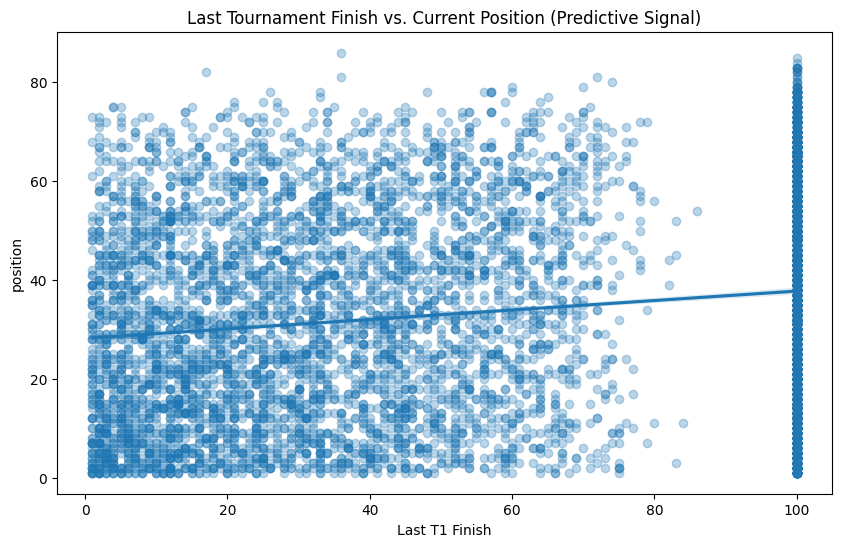

In [228]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

# Rolling Averages for Position (Shifted so we don't leak current tournament data)
for window in [3, 5, 10]:
    df_year[f'Avg_Pos_L{window}'] = df_year.groupby('player')['position'].transform(
        lambda x: x.shift(1).rolling(window=window, min_periods=1).mean()
    )

# Feature Engineering: Rolling Averages for players
df_year = df_year.sort_values(['player', 'Final_Date'])

# Rolling Averages for Position (Shifted so we don't leak current tournament data)
for window in [3, 5, 10]:
    df_year[f'Avg_Pos_L{window}'] = df_year.groupby('player')['position'].transform(
        lambda x: x.shift(1).rolling(window=window, min_periods=1).mean()
    )

# Rolling Averages for To Par
for window in [3, 5]:
    df_year[f'Avg_ToPar_L{window}'] = df_year.groupby('player')['to_par_numeric'].transform(
        lambda x: x.shift(1).rolling(window=window, min_periods=1).mean()
    )

# Course History: Player's avg finish at this specific tournament in previous years
df_year['Avg_Pos_at_Tournament'] = df_year.groupby(['player', 'Tournament'])['position'].transform(
    lambda x: x.shift(1).expanding().mean()
)

df_year['Days_Since_Last_Tournament'] = df_year['Days_Since_Last_Tournament'].fillna(df_year['Days_Since_Last_Tournament'].median())
df_year['Avg_Pos_at_Tournament'] = df_year['Avg_Pos_at_Tournament'].fillna(df_year['position'].mean()) # Fill with global mean if new to tournament

cols_to_fill = [f'Avg_Pos_L{w}' for w in [3, 5, 10]] + [f'Avg_ToPar_L{w}' for w in [3, 5]]
for col in cols_to_fill:
    df_year[col] = df_year[col].fillna(df_year['position'].mean())

le_player = LabelEncoder()
df_year['player_id'] = le_player.fit_transform(df_year['player'])

le_tourney = LabelEncoder()
df_year['tournament_id'] = le_tourney.fit_transform(df_year['Tournament'])

features = [
    'player_id', 'tournament_id', 'Month', 'Year', 
    'Last T1 Finish', 'Days_Since_Last_Tournament', 'Previous_Year_Position',
    'Avg_Pos_L3', 'Avg_Pos_L5', 'Avg_Pos_L10',
    'Avg_ToPar_L3', 'Avg_ToPar_L5', 'Avg_Pos_at_Tournament'
]

# Let's check correlation again with these NEW features
predictive_cols = ['position', 'Avg_Pos_L3', 'Avg_Pos_L5', 'Avg_ToPar_L3', 'Avg_Pos_at_Tournament', 
                   'Days_Since_Last_Tournament', 'Previous_Year_Position', 'Last T1 Finish']

# Filter for rows where we actually have history (Made Cut for position analysis)
predictive_df = df_year[df_year['Made_Cut'] == 1].dropna(subset=['Avg_Pos_L3', 'Avg_Pos_at_Tournament'])
pred_corr = predictive_df[predictive_cols].corr()

print("Correlation of historical features with current Position:")
print(pred_corr['position'].sort_values(ascending=False))

# Visualize the relationship between Last Finish and Current Position
plt.figure(figsize=(10, 6))
sns.regplot(data=predictive_df, x='Last T1 Finish', y='position', scatter_kws={'alpha':0.3})
plt.title('Last Tournament Finish vs. Current Position (Predictive Signal)')

In [229]:
# Player consistency: Standard deviation of their positions
player_stats = df_year[df_year['position'] > 0].groupby('player').agg({
    'position': ['mean', 'std', 'count'],
    'Made_Cut': 'mean'
})
player_stats.columns = ['Avg_Pos', 'Std_Pos', 'Tournament_Count', 'Cut_Made_Rate']

# Filter for players with at least 10 tournaments
consistent_players = player_stats[player_stats['Tournament_Count'] >= 10].sort_values('Avg_Pos')

print("Most Consistent Players (Lowest Std Dev in Position, min 10 tournaments):")
print(consistent_players.head(10))

print("\nTop Players by Cut Made Rate (min 10 tournaments):")
print(player_stats[player_stats['Tournament_Count'] >= 10].sort_values('Cut_Made_Rate', ascending=False).head(10))

Most Consistent Players (Lowest Std Dev in Position, min 10 tournaments):
                     Avg_Pos    Std_Pos  Tournament_Count  Cut_Made_Rate
player                                                                  
Scottie Scheffler   7.964286  10.023544                56            1.0
Rory McIlroy       13.261905  14.759965                42            1.0
Jon Rahm           15.227273  16.118407                22            1.0
Xander Schauffele  16.156863  14.814010                51            1.0
Tommy Fleetwood    18.645833  16.051101                48            1.0
Collin Morikawa    18.978261  16.022885                46            1.0
Russell Henley     19.234043  15.201849                47            1.0
Patrick Cantlay    19.347826  16.073743                46            1.0
Tyrrell Hatton     20.370370  17.435923                27            1.0
Viktor Hovland     21.355556  16.851161                45            1.0

Top Players by Cut Made Rate (min 10 tournaments)

In [230]:
import statsmodels.api as sm

features = ['Last T1 Finish', 'Days_Since_Last_Tournament', 'Previous_Year_Position', 'Avg_Pos_L3', 'Month']
X = df_year[features]
y = df_year['position']

# Drop rows with any remaining NaNs (especially from the rolling shift)
valid_idx = X.dropna().index
X = X.loc[valid_idx]
y = y.loc[valid_idx]

# Add a constant (intercept)
X = sm.add_constant(X)

# 4. Fit the OLS model
model = sm.OLS(y, X).fit()

# 5. Output summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               position   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     22.05
Date:                Mon, 23 Feb 2026   Prob (F-statistic):           4.43e-22
Time:                        09:05:25   Log-Likelihood:                -67146.
No. Observations:               14728   AIC:                         1.343e+05
Df Residuals:                   14722   BIC:                         1.343e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

C:\Users\rfo7799\AppData\Local\Temp\ipykernel_26396\3626962730.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=[features[i] for i in indices], palette='viridis')


Top 5 Features:
1. Avg_Pos_L3: 0.3863
2. Last T1 Finish: 0.2048
3. Month: 0.1601
4. Days_Since_Last_Tournament: 0.1575
5. Previous_Year_Position: 0.0913


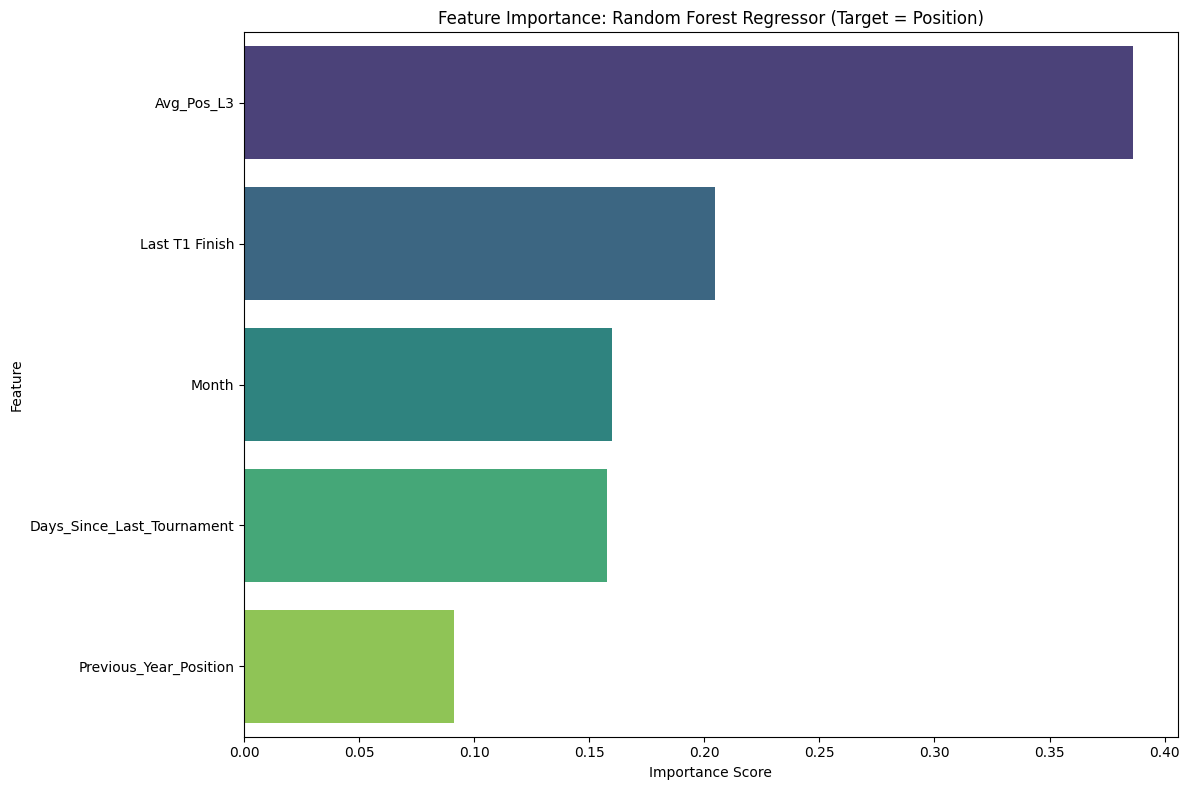

In [231]:
X = df_year[features]
y = df_year['position']

# 5. Train Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 8))
sns.barplot(x=importances[indices], y=[features[i] for i in indices], palette='viridis')
plt.title('Feature Importance: Random Forest Regressor (Target = Position)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()

print("Top 5 Features:")
for i in range(5):
    print(f"{i+1}. {features[indices[i]]}: {importances[indices[i]]:.4f}")

In [233]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Flatten, Dense, Concatenate, Dropout
from tensorflow.keras.models import Model

# 1. Load the engineered data
df = pd.read_csv('engineered_golf_data.csv')

# 2. Setup Features
num_features = [
    'Last T1 Finish', 'Days_Since_Last_Tournament', 'Previous_Year_Position',
    'Avg_Pos_L3', 'Avg_Pos_L5', 'Avg_Pos_L10',
    'Avg_ToPar_L3', 'Avg_ToPar_L5', 'Avg_Pos_at_Tournament', 'Month'
]
target = 'position'

# 3. Data Preparation
X_num = df[num_features].values
X_player = df['player_id'].values
X_tourney = df['tournament_id'].values
y = df[target].values

# Train/Test Split
(X_num_train, X_num_test, 
 X_player_train, X_player_test, 
 X_tourney_train, X_tourney_test, 
 y_train, y_test) = train_test_split(X_num, X_player, X_tourney, y, test_size=0.2)

# Scale numerical features (Crucial for Neural Networks)
scaler = StandardScaler()
X_num_train = scaler.fit_transform(X_num_train)
X_num_test = scaler.transform(X_num_test)

# 4. Building the DNN Architecture
# Player Branch (Embedding learns golfer skill levels)
n_players = df['player_id'].max() + 1
player_input = Input(shape=(1,), name='player_input')
player_embed = Embedding(n_players, 8)(player_input)
player_flat = Flatten()(player_embed)

# Tournament Branch (Embedding learns course characteristics)
n_tourneys = df['tournament_id'].max() + 1
tourney_input = Input(shape=(1,), name='tourney_input')
tourney_embed = Embedding(n_tourneys, 4)(tourney_input)
tourney_flat = Flatten()(tourney_embed)

# Numerical Branch (Handles rolling stats)
num_input = Input(shape=(len(num_features),), name='num_input')

# Merge all branches
concat = Concatenate()([player_flat, tourney_flat, num_input])

# Deep Layers
x = Dense(64, activation='relu')(concat)
x = Dropout(0.2)(x) # Prevents overfitting
x = Dense(32, activation='relu')(x)
x = Dense(16, activation='relu')(x)

# Output (Predicting position rank)
output = Dense(1, activation='linear')(x)

model = Model(inputs=[player_input, tourney_input, num_input], outputs=output)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 5. Training
print("Starting model training...")
model.fit(
    [X_player_train, X_tourney_train, X_num_train], y_train,
    validation_data=([X_player_test, X_tourney_test, X_num_test], y_test),
    epochs=50,
    batch_size=32
)

# 6. Save for later use
#model.save('golf_predictor_dnn.h5')
print("Model saved as golf_predictor_dnn.h5")

ImportError: Traceback (most recent call last):
  File "C:\Users\rfo7799\AppData\Roaming\Python\Python311\site-packages\tensorflow\python\pywrap_tensorflow.py", line 73, in <module>
    from tensorflow.python._pywrap_tensorflow_internal import *
ImportError: DLL load failed while importing _pywrap_tensorflow_internal: A dynamic link library (DLL) initialization routine failed.


Failed to load the native TensorFlow runtime.
See https://www.tensorflow.org/install/errors for some common causes and solutions.
If you need help, create an issue at https://github.com/tensorflow/tensorflow/issues and include the entire stack trace above this error message.